# 1. Import Library

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as skl
import plotly.express as px
import seaborn as sns
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import joblib
import os
print('Loaded libraries successfully.')

Loaded libraries successfully.


# 2. Load & Clean Data

### 2.1 Load Data:

In [40]:
base_path = os.path.join(os.getcwd(), 'data')

# Load files dynamically
df2023 = pd.read_csv(os.path.join(base_path, '2023.csv'))
df2024 = pd.read_csv(os.path.join(base_path, '2024.csv'))
df2025 = pd.read_csv(os.path.join(base_path, '2025.csv'))
df2026 = pd.read_csv(os.path.join(base_path, '2026.csv'))

# Combine dataframes
df = pd.concat([df2023, df2024, df2025, df2026], ignore_index=True)
# Clean up memory
del df2023, df2024, df2025, df2026
# Check combined dataframe
print("Loading Completed!")
print("Dataframe shape:", df.shape)
print("Sample rows:")
df.head()

Loading Completed!
Dataframe shape: (9573, 50)
Sample rows:


,tourney_id,tourney_name,surface,draw_size,tourney_level,indoor,tourney_date,match_num,winner_id,winner_seed,...,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced
0,2023-9900,United Cup,Hard,18.0,A,O,20230102,1.0,GH92,NaN,...,0.0,0.0,0.0,81.0,50.0,37.0,15.0,11.0,3.0,4.0
1,2023-9900,United Cup,Hard,18.0,A,O,20230102,2.0,CG80,8.0,...,10.0,2.0,1.0,70.0,50.0,31.0,8.0,11.0,5.0,9.0
2,2023-9900,United Cup,Hard,18.0,A,O,20230102,3.0,ME82,NaN,...,3.0,2.0,2.0,56.0,37.0,16.0,5.0,6.0,4.0,10.0
3,2023-9900,United Cup,Hard,18.0,A,O,20230102,4.0,RC91,6.0,...,0.0,1.0,3.0,57.0,37.0,22.0,10.0,9.0,4.0,7.0
4,2023-9900,United Cup,Hard,18.0,A,O,20230102,5.0,GH92,NaN,...,4.0,9.0,1.0,104.0,63.0,51.0,21.0,17.0,3.0,5.0


### 2.2 Check Missing values:

Check missing and duplicated values:

In [41]:
# Basic dataframe checks
def check_df(data):
    print(f'Shape          : {data.shape}\n'                # Shape of the dataframe
          f'Size           : {data.size}\n'                 # Total number of elements in the dataframe
          f'Missing values : {data.isnull().sum().sum()}\n' # Total number of missing values in the dataframe
          f'Duplicated     : {data.duplicated().sum()}')    # Total number of duplicated rows in the dataframe

check_df(df)

Shape          : (9573, 50)
Size           : 478650
Missing values : 39581
Duplicated     : 0


### 2.3 Change format DF:

Shorten the format of data from 50 rows to 31 rows:

In [42]:
# Data Cleaning and Formatting
def convert_to_long_format(df):
    """
    convert from wide format to long format
    """
    # 1. Create Match ID by combining tourney_id, winner_id, and loser_id
    df['match_id'] = df['tourney_id'].astype(str) + "_" + df['winner_id'].astype(str)+ "_" + df['loser_id'].astype(str)

    # 2. Maintain common columns for both Winner and Loser groups
    common_cols = ['match_id','tourney_id','tourney_name', 'tourney_date','match_num','surface', 'tourney_level','score','minutes']

    # 3. Create Winner group by removing 'winner_' and 'w_'
    winner_cols = [c for c in df.columns if c.startswith('winner_') or c.startswith('w_')]
    df_winner = df[common_cols + winner_cols].copy()
    df_winner.columns = [c.replace('winner_', 'player_').replace('w_', 'player_') for c in df_winner.columns]

    # 4. Compute result column = 1 (Win) and create opponent_id
    df_winner['result'] = 1
    df_winner['opponent_id'] = df['loser_id']
    df_winner['opponent_name'] = df['loser_name']

    # 5. Create Loser Group by removing 'loser_' and 'l_'
    loser_cols = [c for c in df.columns if c.startswith('loser_') or c.startswith('l_')]
    df_loser = df[common_cols + loser_cols].copy()
    df_loser.columns = [c.replace('loser_', 'player_').replace('l_', 'player_') for c in df_loser.columns]

    # 6. Compute result column = 0 (Loss) and create opponent_id
    df_loser['result'] = 0
    df_loser['opponent_id'] = df['winner_id']
    df_loser['opponent_name'] = df['winner_name']

    # 7. Concatenate winner and loser tables
    df_long = pd.concat([df_winner, df_loser], ignore_index=True)

    # 8. Sort by match_id to ensure that winner and loser of the same match are adjacent
    df_long = df_long.sort_values(by=['match_id']).reset_index(drop=True)

    return df_long


In [43]:
# Convert to long format and check results:
df_new = convert_to_long_format(df)
print("Previous Data shape: ", df.shape)
print("New Data shape.    : ", df_new.shape)
print("Sample row:")
df_new.head(5)

Previous Data shape:  (9573, 51)
New Data shape.    :  (19146, 31)
Sample row:


,match_id,tourney_id,tourney_name,tourney_date,match_num,surface,tourney_level,score,minutes,player_id,...,player_svpt,player_1stIn,player_1stWon,player_2ndWon,player_SvGms,player_bpSaved,player_bpFaced,result,opponent_id,opponent_name
0,2023-1536_A0E2_CG80,2023-1536,Madrid Masters,20230424,94.0,Clay,M,6-4 6-3,100.0,A0E2,...,58.0,38.0,27.0,13.0,9.0,1.0,2.0,1,CG80,Borna Coric
1,2023-1536_A0E2_CG80,2023-1536,Madrid Masters,20230424,94.0,Clay,M,6-4 6-3,100.0,CG80,...,62.0,38.0,23.0,10.0,10.0,2.0,6.0,0,A0E2,Carlos Alcaraz
2,2023-1536_A0E2_D875,2023-1536,Madrid Masters,20230424,80.0,Clay,M,6-2 7-5,90.0,A0E2,...,51.0,35.0,26.0,12.0,10.0,1.0,2.0,1,D875,Grigor Dimitrov
3,2023-1536_A0E2_D875,2023-1536,Madrid Masters,20230424,80.0,Clay,M,6-2 7-5,90.0,D875,...,54.0,29.0,18.0,12.0,10.0,2.0,6.0,0,A0E2,Carlos Alcaraz
4,2023-1536_A0E2_KE29,2023-1536,Madrid Masters,20230424,92.0,Clay,M,6-4 7-5,110.0,KE29,...,72.0,47.0,30.0,14.0,11.0,3.0,6.0,0,A0E2,Carlos Alcaraz


### 2.4 Clean up:

Filter out not related columns and null:

In [44]:
df_new = df_new[df_new['score'] != 'W/O']                      # Remove walkover matches
df_new = df_new[df_new['match_num'].notnull()]                 # Remove matches with missing match number
df_new = df_new[df_new['player_rank']<=30]                     # Top 30 rank
df_new = df_new[~df_new['tourney_name'].str.contains('Davis')] # Not include Davis CUP
df_new = df_new[df_new['player_SvGms'].notnull()]              # Remove missing points data
df_new = df_new[~df_new['score'].str.contains('RET')]          # Remove matches with retirement
df_new = df_new.drop(columns=['surface', 'player_seed', 'player_entry'], errors='ignore')   # Drop columns that are not relevant or have too many missing values
df_new['tourney_name'] = df_new['tourney_name'].replace('Rio de Janeiro', 'Rio De Janeiro') # Standardize tournament name
print("Data shape after cleaning: ")
check_df(df_new)
missing = pd.DataFrame(df_new.isnull().sum(), columns=['missing_count'])
print("\n", missing[missing['missing_count'] > 0])

Data shape after cleaning: 
Shape          : (4897, 28)
Size           : 137116
Missing values : 244
Duplicated     : 0

          missing_count
minutes            244


### 2.5 Impute Missing value:

Fill missing minutes by AVG minutes for set:

In [45]:
# 1. Parse sets by score:
def count_sets(score_str):
    if pd.isna(score_str) or score_str in ['W/O', 'DEF', 'RET']:
        return None
    sets = str(score_str).split()
    return len(sets)

# Count Set
df_new['set_count'] = df_new['score'].apply(count_sets)

# 2. AVG minutes by set_count:
avg_minutes_by_set = df_new.groupby('set_count')['minutes'].mean().round(0).reset_index()
print("AVG Minutes by set:")
display(avg_minutes_by_set)

# 3. Fill in missing minutes values:
def fill_minutes(row):
    if pd.isna(row['minutes']):
        return avg_minutes_by_set[avg_minutes_by_set['set_count'] == row['set_count']]['minutes'].values[0]
    return row['minutes']

df_new['minutes'] = df_new.apply(fill_minutes, axis=1)
print("Data shape after filling missing minutes: ")
check_df(df_new)

# 4. Delete set_count column as it is no longer needed:
df_new = df_new.drop(columns=['set_count'])

AVG Minutes by set:


,set_count,minutes
0,2,90.0
1,3,141.0
2,4,182.0
3,5,232.0


Data shape after filling missing minutes: 
Shape          : (4897, 29)
Size           : 142013
Missing values : 0
Duplicated     : 0


### 2.6 Save Clean Data:

Check new cleanned, formatted data and saved it.

In [46]:
df_new.to_csv('/Users/lukesfolder/Desktop/Project/Tennis/data/formatted-data.csv', index=False)
print("Data cleaning and formatting completed. Cleaned data saved to 'formatted-data.csv'.")

Data cleaning and formatting completed. Cleaned data saved to 'formatted-data.csv'.


# 3. EDA

### 3.1 Top 20 ATP Single:

In [47]:
#1. Filter to top 20 players based on player_rank:
df_top20 = df_new[df_new['player_rank'] <= 20]                      # Filter to top 20 players

#2. Group by player_name and player_ioc, then calculate stats:
top20_stats = df_top20.groupby(['player_name','player_ioc']).agg(
    age = ('player_age', 'max'),                                    # Latest age in the dataset
    total_matches = ('match_id', 'count'),                          # Total matches played
    ranking_points = ('player_rank_points', 'max'),                 # Latest ranking points in the dataset
    wins = ('result', 'sum'),                                       # Total wins (result=1)               
    losses = ('result', lambda x: (x==0).sum()),                    # Total losses (result=0)  
    win_rate = ('result', 'mean'),                                  # Average win rate across all matches
    avg_minutes = ('minutes', 'mean')).reset_index()                # Average match duration in minutes

#3. Sort by ranking points and assign rank:
top20_stats = top20_stats.sort_values(by='ranking_points', ascending=False).reset_index(drop=True)          # Sort by ranking points in descending order
top20_stats['rank'] = top20_stats.index + 1                                                                 # Assign rank based on sorted order (1 to 20)
top20_stats['age'] = top20_stats['age'].astype(int)                                                         # Convert age to integer
top20_stats['win_rate'] = top20_stats['win_rate'].round(2) * 100                                            # Convert win_rate to percentage and round to 2 decimal places
top20_stats['ranking_points'] = top20_stats['ranking_points'].astype(int)                                   # Convert ranking points to integer
top20_stats['avg_minutes'] = top20_stats['avg_minutes'].round(2)                                            # Round average minutes to 2 decimal places
top20_stats = top20_stats[['rank', 'player_name', 'player_ioc', 'age', 'total_matches', 
                           'wins', 'losses', 'win_rate', 'ranking_points', 'avg_minutes']]                  # Reorder columns
print("Top 20 Players Stats:")
top20_stats.head(20)

Top 20 Players Stats:


,rank,player_name,player_ioc,age,total_matches,wins,losses,win_rate,ranking_points,avg_minutes
0,1,Carlos Alcaraz,ESP,22,207,175,32,85.0,13150,125.81
1,2,Jannik Sinner,ITA,24,200,175,25,88.0,11830,125.40
2,3,Novak Djokovic,SRB,38,146,122,24,84.0,11245,137.54
3,4,Alexander Zverev,GER,28,221,158,63,71.0,8135,129.56
4,5,Daniil Medvedev,RUS,30,210,152,58,72.0,8015,118.86
5,6,Rafael Nadal,ESP,36,4,1,3,25.0,6020,174.75
6,7,Stefanos Tsitsipas,GRE,26,162,108,54,67.0,5940,117.49
7,8,Casper Ruud,NOR,27,181,118,63,65.0,5820,120.13
8,9,Taylor Fritz,USA,28,218,148,70,68.0,5350,116.21
9,10,Andrey Rublev,RUS,28,209,134,75,64.0,5110,115.49


### 3.2 Tour level top winner

In [48]:
# 1. Create table by tournament, level, and player:
tour_stats = df_new.groupby(['tourney_level','player_name']).agg(
    age = ('player_age', 'max'),                    # Latest age in the dataset
    total_matches = ('match_id', 'count'),          # Total matches played in the tournament
    wins = ('result', 'sum'),                       # Total wins (result=1)
    losses = ('result', lambda x: (x==0).sum()),    # Total losses (result=0)
    win_rate = ('result', 'mean'),                  # Average win rate across all matches in the tournament
    rank = ('player_rank', 'min')                   # Latest rank in the tournament
).reset_index()

# 2. Sort by Top wins and calculate win rate:
tour_stats = tour_stats.sort_values(by=['tourney_level', 'wins'], ascending=[True, False])                                               # Sort by tournament and highest wins
tour_stats['age'] = tour_stats['age'].astype(int)                                                                                       # Convert age to integer
tour_stats['win_rate'] = tour_stats['win_rate'].round(2) * 100                                                                          # Winrate calculation
tour_stats = tour_stats[['tourney_level', 'player_name', 'age','rank', 'total_matches', 'wins', 'losses', 'win_rate']]   # Reorder columns

# 3. Filter Top player for each tournament:
tour_stats_sorted = tour_stats.groupby('tourney_level').head(1).reset_index(drop=True)

#4. Display the top player for each tournament
tour_stats_sorted

,tourney_level,player_name,age,rank,total_matches,wins,losses,win_rate
0,250,Taylor Fritz,28,4.0,47,37,10,79.0
1,500,Alex de Minaur,27,6.0,64,47,17,73.0
2,A,Alexander Zverev,28,2.0,16,10,6,62.0
3,F,Jannik Sinner,24,1.0,15,14,1,93.0
4,G,Novak Djokovic,38,1.0,68,61,7,90.0
5,M,Jannik Sinner,24,1.0,68,58,10,85.0
6,O,Novak Djokovic,37,2.0,6,6,0,100.0


### 3.3 Fatigue factor:

The Fatigue Factor is defined as the correlation between a player's cumulative time on court (total minutes played) within a specific tournament and their subsequent win probability.

Hypothesis: As a player accumulates significant physical exertion through extended match durations in earlier rounds, their performance efficiency may decrease, leading to a statistically significant decline in win rates during later stages of the tournament.

In [49]:
#1. Sorting data with match order
df_fatigue = df_new.sort_values(by=['tourney_id', 'player_id','match_num'])

#2. Create function to accumulate the on court minutes
def acc_minutes(series):
  return series.shift(1).fillna(0).cumsum() # Shift first record to avoid counting current match minutes, fill NA with 0, then cumulative sum

#3. Create new acc_minutes columns:
df_fatigue['acc_played_minutes'] = df_fatigue.groupby(['tourney_id', 'player_id'])['minutes'].transform(acc_minutes)

# 4. Bins
bins = [-1, 0, 150, 300, 450, 600, np.inf]
labels = ['0 mins (First Match)', '1-150 mins', '151-300 mins', '301-450 mins', '451-600 mins', '600+ mins']

# 5. Added label column
df_fatigue['bin_minutes'] = pd.cut(df_fatigue['acc_played_minutes'], bins=bins, labels=labels)

# 6. Win Rate by grouped bins
fatigue_eda = df_fatigue.groupby('bin_minutes', observed=False)['result'].agg(
    total_matches='count',
    win_rate='mean'
).reset_index()

# 7. Plot
fig = px.bar(
    fatigue_eda,
    x='bin_minutes',
    y='win_rate',
    text_auto='.1%', # percentage
    title='<b> Fatigue and Win Rate </b>',
    labels={'fatigue_level': 'Totol played minutes', 'win_rate': ' Win Rate'},
    color='win_rate',
    color_continuous_scale='RdYlGn' #
)

fig.update_layout(yaxis_tickformat='.0%')
fig.show()


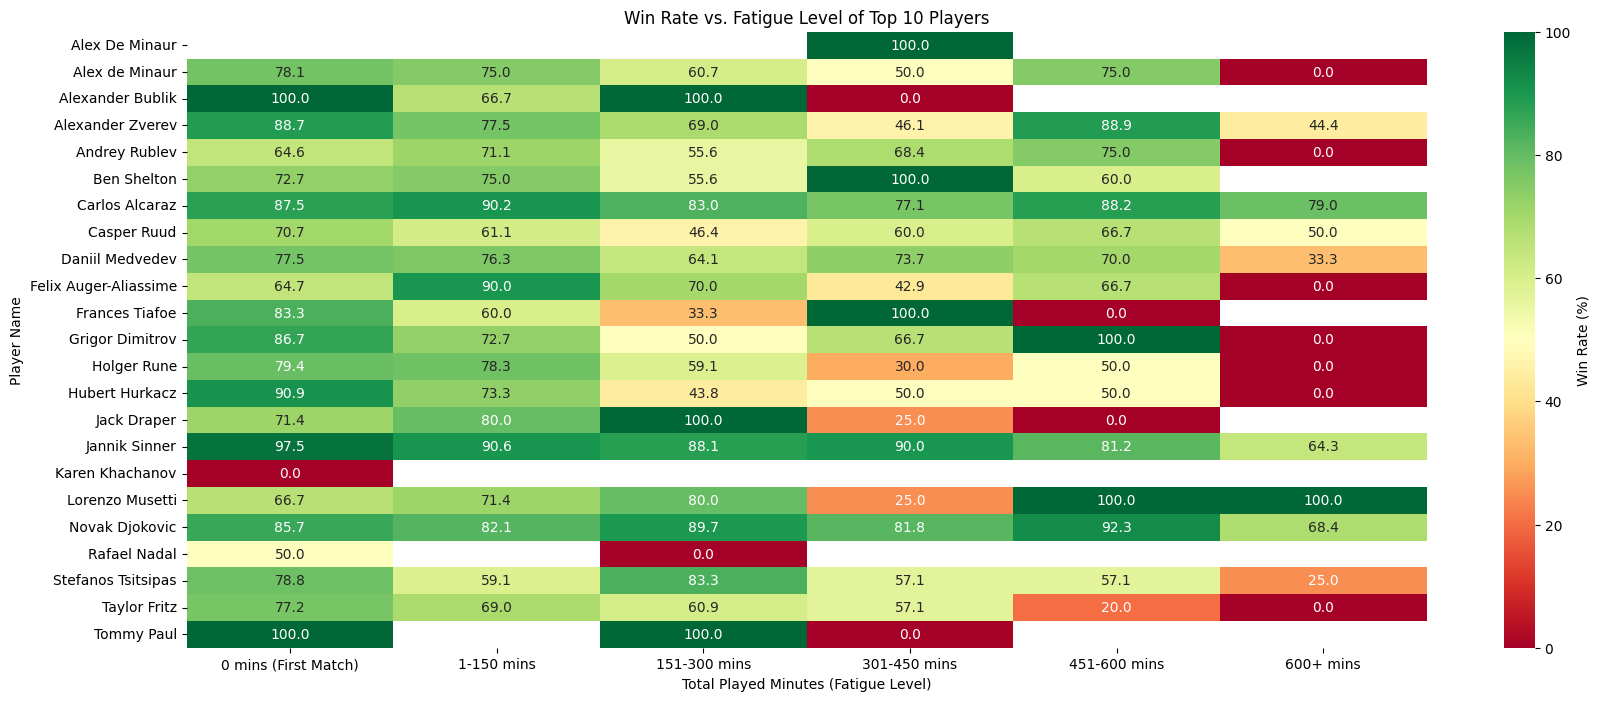

In [50]:
#1. Filter to top 10 players based on player_rank:
top10 = df_fatigue[df_fatigue['player_rank'] <= 10]

#2. Group by player_name and fatigue bins, then calculate win rate:
fatigue_eda_player = top10.groupby(['player_name','bin_minutes'], observed=False)['result'].agg(
    total_matches='count',         # Count total matches 
    win_rate='mean').reset_index() # Calculate win rate 
fatigue_eda_player['win_rate'] = round(fatigue_eda_player['win_rate']*100,2)
fatigue_eda_player = fatigue_eda_player[fatigue_eda_player['total_matches'] > 0] # Filter out combinations with no matches to avoid NaN in heatmap

# 3. Pivot for heatmap
fatigue_eda_player = fatigue_eda_player.pivot(index='player_name', columns='bin_minutes', values='win_rate')
plt.figure(figsize=(20, 8))
sns.heatmap(fatigue_eda_player, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Win Rate (%)'})
plt.title('Win Rate vs. Fatigue Level of Top 10 Players')
plt.xlabel('Total Played Minutes (Fatigue Level)')
plt.ylabel('Player Name')
plt.show()

### 3.4 Correlation Maxtrix

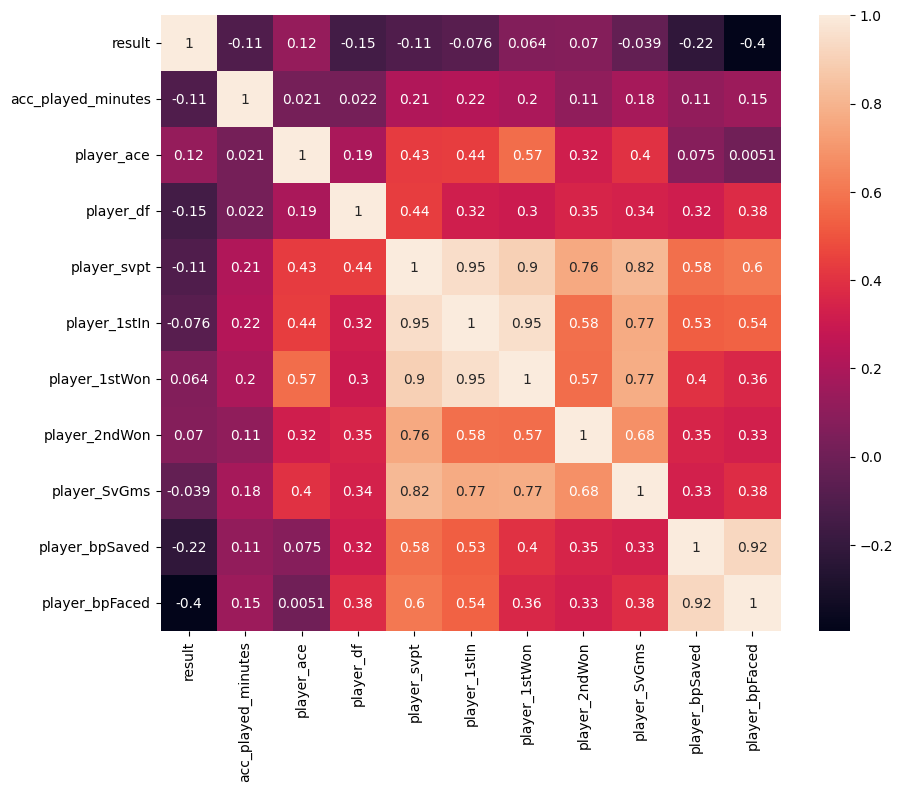

In [51]:
# 1. Points, minutes columns:
cols_to_correlate = [
    'result','acc_played_minutes', 'player_ace', 'player_df',
    'player_svpt', 'player_1stIn', 'player_1stWon',
    'player_2ndWon', 'player_SvGms','player_bpSaved','player_bpFaced']

# 2. Correlation matrix:
df_corr = df_fatigue[cols_to_correlate]
corr_matrix = df_corr.corr()

#3 Heatmap:
fig, ax = plt.subplots(figsize=(10, 8))
fig = sns.heatmap(corr_matrix, annot=True)

# 4. Feature Engineering

### 4.1 AVG 10 games ratio

1st Serve in, 1st Serve won the game, Ace, Save breakpoint


In [52]:
dflatest = df_fatigue.copy()

# 1. Sorting Data
dflatest = dflatest.sort_values(by=['player_id', 'tourney_date', 'match_num'])

# 2. New feature with Clipping (Max = 1)
dflatest['1st_srv_in'] = (dflatest['player_1stIn'] / dflatest['player_svpt']).clip(upper=1)
dflatest['1st_srv_won'] = (dflatest['player_1stWon'] / dflatest['player_1stIn']).clip(upper=1)
dflatest['bp_save_rate'] = (dflatest['player_bpSaved'] / dflatest['player_bpFaced']).clip(upper=1)
dflatest['ace_per_game'] = dflatest['player_ace'] / dflatest['player_SvGms'] # Ace per game có thể > 1 nên không clip

# 3. Moving Average (current 10 match)
def get_rolling_avg(group, col_name, window=10):
    # shift(1) giúp tránh "Data Leakage" (lấy dữ liệu tương lai dự đoán quá khứ)
    return group[col_name].shift(1).rolling(window=window, min_periods=1).mean()

# 4. Apply to features
features_to_roll = ['1st_srv_in', '1st_srv_won', 'bp_save_rate', 'ace_per_game', 'minutes']
for col in features_to_roll:
    new_col_name = f'avg_{col}_last_10'
    # Groupby player_id và tính toán giá trị trung bình trượt
    dflatest[new_col_name] = dflatest.groupby('player_id')[col].transform(lambda x: get_rolling_avg(dflatest.loc[x.index], col))

# 5. Check Taylor Fritz (Top Server)
cols_view = ['player_name', 'avg_1st_srv_in_last_10', 'avg_1st_srv_won_last_10',
       'avg_bp_save_rate_last_10', 'avg_ace_per_game_last_10']
dflatest[dflatest['player_name'] == 'Taylor Fritz'][cols_view].head(10)

,player_name,avg_1st_srv_in_last_10,avg_1st_srv_won_last_10,avg_bp_save_rate_last_10,avg_ace_per_game_last_10
5469,Taylor Fritz,NaN,NaN,NaN,NaN
5470,Taylor Fritz,0.602941,0.780488,1.000000,0.500000
5510,Taylor Fritz,0.601471,0.871725,1.000000,0.694444
5467,Taylor Fritz,0.604489,0.805288,0.833333,0.796296
5464,Taylor Fritz,0.609617,0.823966,0.875000,0.826389
4053,Taylor Fritz,0.610046,0.832250,0.875000,0.911111
4146,Taylor Fritz,0.618933,0.832845,0.800000,1.025926
2382,Taylor Fritz,0.625482,0.821315,0.772727,0.990476
2380,Taylor Fritz,0.631281,0.832023,0.772727,0.980303
2420,Taylor Fritz,0.634766,0.830485,0.662338,0.938047


### 4.2 H2H Win Rate

Totol win / total H2H matches

In [53]:
#1. Sorting:
dflatest = dflatest.sort_values(by=['player_name', 'opponent_name', 'tourney_date', 'match_num']).reset_index(drop=True)

# 2. Total H2H Wins
dflatest['h2h_wins'] = dflatest.groupby(['player_name', 'opponent_name'])['result'].transform(lambda x: x.shift(1).fillna(0).cumsum())

# 3. Total H2H matches
dflatest['h2h_total_matches'] = dflatest.groupby(['player_name', 'opponent_name']).cumcount() 

# 4. H2H Win Rate
dflatest['h2h_win_rate'] = np.where(
    dflatest['h2h_total_matches'] > 0,
    dflatest['h2h_wins'] / dflatest['h2h_total_matches'],
    0.5 ) # If never meet 50-50%

# Check Sinner vs Djokovic
cols_to_view = ['tourney_date','tourney_name', 'player_name', 'opponent_name','result', 'h2h_wins', 'h2h_total_matches', 'h2h_win_rate' ]
(dflatest[(dflatest['player_name'] == 'Jannik Sinner') & (dflatest['opponent_name'] == 'Novak Djokovic')][cols_to_view])

,tourney_date,tourney_name,player_name,opponent_name,result,h2h_wins,h2h_total_matches,h2h_win_rate
3175,20230703,Wimbledon,Jannik Sinner,Novak Djokovic,0,0.0,0,0.500000
3176,20231113,Tour Finals,Jannik Sinner,Novak Djokovic,1,0.0,1,0.000000
3177,20231113,Tour Finals,Jannik Sinner,Novak Djokovic,0,1.0,2,0.500000
3178,20240115,Australian Open,Jannik Sinner,Novak Djokovic,1,1.0,3,0.333333
3179,20241002,Shanghai Masters,Jannik Sinner,Novak Djokovic,1,2.0,4,0.500000
3180,20250526,Roland Garros,Jannik Sinner,Novak Djokovic,1,3.0,5,0.600000
3181,20250630,Wimbledon,Jannik Sinner,Novak Djokovic,1,4.0,6,0.666667
3182,20260130,Australian Open,Jannik Sinner,Novak Djokovic,0,5.0,7,0.714286


# 5. Model Training & Evaluation

### 5.1. Data Preparation: Split & Scaling
To ensure our model generalizes well to future matches, we perform a Time-Series Split (80% Train, 20% Test) rather than a random shuffle. 

We also apply Z-score Scaling and calculate a `scale_pos_weight` to address class imbalance.

In [54]:
# 0. Sorting Data Time Series:
dflatest = dflatest.sort_values(by=['tourney_date', 'match_num']).reset_index(drop=True)

# 1. Features and Target:
ml_features = [
    'player_ht', 'player_rank', 'player_rank_points',
    'acc_played_minutes',
    'avg_1st_srv_won_last_10', 'avg_bp_save_rate_last_10',
    'avg_ace_per_game_last_10',
    'h2h_total_matches', 'h2h_win_rate'
]
target = 'result'

# 2. Create ML dataframe:
df_ml = dflatest[ml_features + [target]].reset_index(drop=True)
print(f"1. Dataframe for ML: {df_ml.shape[0]} matches.")

# 3. Checking Missing Values:
missing = df_ml.isnull().sum()
print("2. Missing values per column:")
print(missing[missing > 0])

# 4. Split 80% Train - 20% Test:
split_index = int(len(df_ml) * 0.8)
train_df = df_ml.iloc[:split_index]
test_df = df_ml.iloc[split_index:]

X_train = train_df.drop(columns=[target])
y_train = train_df[target]
X_test = test_df.drop(columns=[target])
y_test = test_df[target]

print(f"3. Shape Train set: {X_train.shape[0]} matches | Test set : {X_test.shape[0]} Matches.")

# 4. Impute missing values:
imputer = SimpleImputer(strategy='mean') # Impute using mean value calculated from the training set
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
print("4. Missing values imputed successfully.")

# 5. Scale features:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
print("5. Scaled features successfully.")

# 6. Calculate Weight_ratio for XGBoost (Handling class imbalance in the training set)
weight_ratio = float(np.sum(y_train == 0)) / np.sum(y_train == 1)
print(f"6. Scale_pos_weight for XGBoost: {weight_ratio:.4f}")

1. Dataframe for ML: 4897 matches.
2. Missing values per column:
avg_1st_srv_won_last_10     63
avg_bp_save_rate_last_10    65
avg_ace_per_game_last_10    63
dtype: int64
3. Shape Train set: 3917 matches | Test set : 980 Matches.
4. Missing values imputed successfully.
5. Scaled features successfully.
6. Scale_pos_weight for XGBoost: 0.5562


### 5.2. Establishing Baselines (Logistic Regression & Random Forest)
We use Logistic Regression as a linear baseline and Random Forest as a non-linear baseline. Both models utilize class_weight='balanced' to prevent bias toward the majority class.

**Why Class Balancing?**

In dataset, match outcomes may not be perfectly distributed. By using `class_weight='balanced'`, we prevent the model from becoming biased toward the majority class. The algorithm automatically assigns higher importance to the minority class, ensuring that the model learns to identify both wins and losses effectively, leading to a more robust F1-Macro score.

**Why F1-Macro?**

F1-Macro is the arithmetic mean of all per-class F1-scores. It is the gold standard for evaluating models on imbalanced datasets, such as tennis match predictions where wins and losses are not evenly distributed.

In [55]:
# 1. Baseline Logistic Regression with class_weight='balanced'
lr_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')          # class_weight='balanced'
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print("1. Classification Report (LR Balanced):")
print(classification_report(y_test, lr_preds))

# 2. Random Forest with class_weight='balanced'
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')   # class_weight='balanced' for Random Forest
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
print("2. Classification Report (RF Balanced):")
print(classification_report(y_test, rf_preds))

1. Classification Report (LR Balanced):
              precision    recall  f1-score   support

           0       0.42      0.72      0.53       326
           1       0.78      0.49      0.60       654

    accuracy                           0.57       980
   macro avg       0.60      0.61      0.57       980
weighted avg       0.66      0.57      0.58       980

2. Classification Report (RF Balanced):
              precision    recall  f1-score   support

           0       0.54      0.32      0.40       326
           1       0.72      0.87      0.79       654

    accuracy                           0.68       980
   macro avg       0.63      0.59      0.59       980
weighted avg       0.66      0.68      0.66       980



### 5.3. XGBoost Optimization & Hyperparameter Tuning:
Finally, we implement XGBoost. We use a manual weighted version first, followed by GridSearchCV to find the optimal combination of depth, learning rate, and estimator count, using F1-Macro as the primary evaluation metric to ensure performance across both win and loss predictions.

In [56]:
# 1. Manual weighted XGBoost using scale_pos_weight
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=weight_ratio,  # adding weight_ratio
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3)

xgb_model.fit(X_train_scaled, y_train)
xgb_bal_preds = xgb_model.predict(X_test_scaled)
print("3. Classification Report (XGB Manual Weighted):")
print(classification_report(y_test, xgb_bal_preds))

# 2. Define parameter grid for GridSearchCV
print("4. Fine tunning XGBoost:")
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]}

# 3. Gridsearch Cross-Validation (cv=3)
grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=weight_ratio),
    param_grid=param_grid,
    scoring='f1_macro',     # F1-Macro i/o  Accuracy
    cv=3,                   # 3-fold cross-validation
    n_jobs=-1,              # All core CPU
    verbose=1)


# 4. Fit again with GridSearchCV
grid_search.fit(X_train_scaled, y_train)

# 5. Best model
best_xgb = grid_search.best_estimator_
best_preds = best_xgb.predict(X_test_scaled)

print(f"\n5. Best param: {grid_search.best_params_}")
print(classification_report(y_test, best_preds))

3. Classification Report (XGB Manual Weighted):
              precision    recall  f1-score   support

           0       0.44      0.70      0.54       326
           1       0.79      0.56      0.66       654

    accuracy                           0.61       980
   macro avg       0.62      0.63      0.60       980
weighted avg       0.67      0.61      0.62       980

4. Fine tunning XGBoost:
Fitting 3 folds for each of 12 candidates, totalling 36 fits

5. Best param: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.43      0.54      0.48       326
           1       0.74      0.65      0.69       654

    accuracy                           0.61       980
   macro avg       0.59      0.59      0.58       980
weighted avg       0.64      0.61      0.62       980



### 5.4  Feature Importance:
After optimizing the XGBoost model, we analyze Feature Importance to identify which variables most significantly impact match outcomes. This step is crucial for model interpretability, allowing us to "open the black box" and verify if the AI's logic aligns with real-world tennis dynamics, such as the influence of player rank or recent serving performance.

/var/folders/n1/pyprlpq57bg8kymbwrtkz6140000gn/T/ipykernel_72238/1849228687.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')


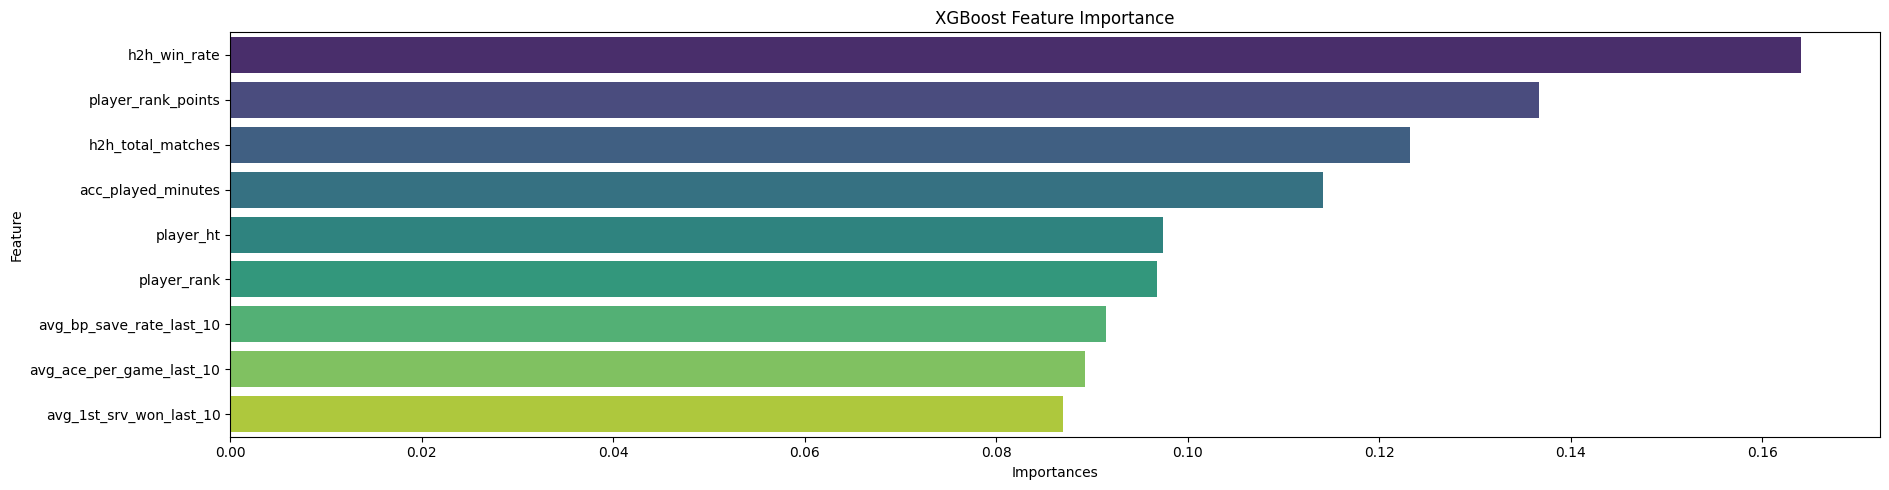

In [57]:
# 1. Importances score from best model
importances = best_xgb.feature_importances_

# 2. Importances name
feature_names = X_train.columns

# 3. Data frame
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances})

df_importance = df_importance.sort_values(by='Importance', ascending=False)

# 4. Plot
plt.figure(figsize=(19, 5))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importances')
plt.tight_layout()
plt.show()

In [58]:
feature_names

Index(['player_ht', 'player_rank', 'player_rank_points', 'acc_played_minutes',
       'avg_1st_srv_won_last_10', 'avg_bp_save_rate_last_10',
       'avg_ace_per_game_last_10', 'h2h_total_matches', 'h2h_win_rate'],
      dtype='object')